# Analisis y Modelado de Dinamica Costera trimestral

Este notebook interactivo ha sido diseñado para estudiar, analizar y modelar la relacion entre la **dinamica de la linea de costa (CoastSat)** y las **variables oceanograficas y climaticas (ERA5) y el Servicio Marino de Copernicus CMEMS** en diferentes playas.

Se trata de experimentar con los conceptos de geomorfologia costera estadistica, comparar playas y entrenar modelos autorregresivos (ARDL) con  datos integrados.

---

### EOF / PCA (Funciones Empiricas Ortogonales y Análisis de Componentes Principales )

*   **Las Funciones Empiricas Ortogonales  (EOF / PCA)** son metodo totalmente basado en datos (data-driven) que **descompone de forma automatica y simultanea** los diferentes patrones espaciales de variabilidad:
*   **EOF 1 (Tipicamente ~80-90% de la varianza):** Captura el comportamiento síncrono y volumetrico neto de la playa (toda la costa retrocede o avanza a la vez bajo la influencia de oleaje energetico o mareas de tempestad).
*   **EOF 2 (Tipicamente ~5-15% de la varianza):** Captura la **rotacion de la playa** (los coeficientes espaciales tienen signos opuestos en los extremos de la playa). Esto nos dice que cuando el norte avanza, el sur retrocede, y viceversa, impulsado por cambios en la direccion dominante del oleaje y viento.
*   PCA extrae de forma pura y ortogonal (independiente) ambos procesos fisicos reales. Por ende, es adecuado para el modelado



## 2. Inicializacion e Importacion de Librerias

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="ticks", palette="muted")
print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Seleccion del Sitio de Estudio

Selección del sitio para analizar. 
Escribir el nombre exacto de la carpeta bajo `data/` (ej. `'RBMN_2a'`, `'CaboPulmo'`, `'CostaPalma'`).

In [ ]:
# Define aqui la playa de estudio
SITENAME = 'RBMN_1'

# Directorio del proyecto
BASE_DIR = os.getcwd()
CSV_PATH = os.path.join(BASE_DIR, 'data', SITENAME, f'{SITENAME}_combined_promedios_estacionales.csv')

print(f"📂 Sitio configurado para analisis: {SITENAME}")
print(f"📍 Buscando archivo combinado en: {CSV_PATH}")
if os.path.exists(CSV_PATH):
    print("✅ Archivo encontrado y listo.")
else:
    print("❌ ERROR: No se encontro el archivo combinado. Ejecuta primero la extraccion de ERA5 para este sitio.")

📂 Sitio configurado para analisis: RBMN_1
📍 Buscando archivo combinado en: d:\coastsat25\data\RBMN_1\RBMN_1_combined_promedios_estacionales.csv
✅ Archivo encontrado y listo.


## 4. Carga de Datos y Limpieza (Imputacion de NaNs)

Las series de CoastSat pueden no tener datos por artefactos en las imágenes (normalmente nubes). Para aplicar PCA de forma segura, se realiza una **interpolacion lineal temporal** de los transectos y las variables de ERA5, y se eliminan las filas extremas huerfanas.

In [ ]:
# Leer el CSV combinado
df = pd.read_csv(CSV_PATH)
df['Fecha'] = pd.to_datetime(df['Fecha'])
df = df.sort_values(by='Fecha').reset_index(drop=True)

# Identificar columnas de transectos y de clima
transect_cols = [col for col in df.columns if col.startswith('tr_')] #Ojo con como empieza el nombre de los transectos
era5_cols = [
    'sst_celsius', 
    'wind_speed_m_s', 
    'wind_dir_deg', 
    'significant_wave_height_m', 
    'mean_wave_dir_deg'    
]

# 🆕 Definir columnas de Copernicus
copernicus_cols = ['sla_copernicus', 'adt_copernicus']
print(f"📊 Total de transectos: {len(transect_cols)}")
print(f"📈 Registros historicos originales: {len(df)} periodos estacionales.\n")

# Limpieza mediante interpolacion temporal
df_clean = df.copy()
df_clean[transect_cols] = df_clean[transect_cols].interpolate(method='linear', limit_direction='both')
df_clean[era5_cols] = df_clean[era5_cols].interpolate(method='linear', limit_direction='both')

# 🆕 Limpieza/Interpolación de variables de Copernicus
df_clean[copernicus_cols] = df_clean[copernicus_cols].interpolate(method='linear', limit_direction='both')
# Dropear filas que aun contengan NaNs insalvables (incluyendo Copernicus)
df_clean = df_clean.dropna(subset=transect_cols + era5_cols + copernicus_cols).reset_index(drop=True)
print(f"✅ Registros limpios despues de interpolacion: {len(df_clean)} trimestres.")

df_clean.head(3)

📊 Total de transectos: 311
📈 Registros historicos originales: 123 periodos estacionales.

✅ Registros limpios despues de interpolacion: 123 trimestres.


,Fecha,tr_rbmn_1,tr_rbmn_2,tr_rbmn_3,tr_rbmn_4,tr_rbmn_5,tr_rbmn_6,tr_rbmn_7,tr_rbmn_8,tr_rbmn_9,...,sst_kelvin,sst_celsius,u_wind_10m,v_wind_10m,wind_speed_m_s,wind_dir_deg,significant_wave_height_m,mean_wave_dir_deg,sla_copernicus,adt_copernicus
0,1995-01-01,229.906121,269.516229,291.815435,304.997175,305.541475,297.179966,315.74785,329.041276,330.792790,...,297.648317,24.498317,1.876917,-2.060551,2.791966,133.218736,2.191838,240.419981,0.012761,0.639345
1,1995-04-01,229.906121,269.516229,291.815435,304.997175,305.541475,297.179966,315.74785,329.041276,346.558423,...,297.202076,24.052076,2.316564,-0.855884,2.485632,160.771693,0.981105,236.647003,-0.068491,0.558092
2,1995-07-01,229.906121,269.516229,291.815435,304.997175,305.541475,297.179966,315.74785,329.041276,347.016592,...,294.363092,21.213092,1.193126,0.397706,1.257741,198.482816,1.360057,183.326954,0.068584,0.695168


## 5. Analisis de Funciones Ortogonales Empiricas (EOF / PCA)

Cálculo del PCA sobre la matriz de transectos centrandola (restando la media de cada transecto). Esto permite ver de forma pura los modos dominantes de la linea de costa.

In [9]:
X_transects = df_clean[transect_cols].values

# Centrar los datos respecto a la media de cada transecto
scaler = StandardScaler(with_std=False) 
X_centered = scaler.fit_transform(X_transects)

# Ajustar el PCA
n_components = min(5, len(transect_cols))
pca = PCA(n_components=n_components)
PCs = pca.fit_transform(X_centered)

# Guardar resultados en el DataFrame
for i in range(min(3, n_components)):
    df_clean[f'EOF_{i+1}'] = PCs[:, i]

# Imprimir varianza explicada
explained_variance = pca.explained_variance_ratio_ * 100
print("🔮 PATRONES ESPACIALES EXTRAIDOS (Varianza Explicada):")
for idx, var in enumerate(explained_variance):
    print(f"   EOF {idx+1}: {var:.2f}%")
print(f"   Varianza acumulada (Top 3): {sum(explained_variance[:3]):.2f}%")

🔮 PATRONES ESPACIALES EXTRAIDOS (Varianza Explicada):
   EOF 1: 71.47%
   EOF 2: 18.28%
   EOF 3: 3.60%
   EOF 4: 2.04%
   EOF 5: 1.24%
   Varianza acumulada (Top 3): 93.35%


### Visualizacion del Comportamiento Espacial de los EOFs
Gráfica de la estructura espacial de los primeros componentes principales. 
*   Si los coeficientes de un EOF son todos del **mismo signo** (ej. todos positivos), representa **erosion/acreción uniforme** (EOF 1).
*   Si los coeficientes **cambian de signo** a lo largo de la costa, representa **rotación de la playa** o deriva diferencial (EOF 2).

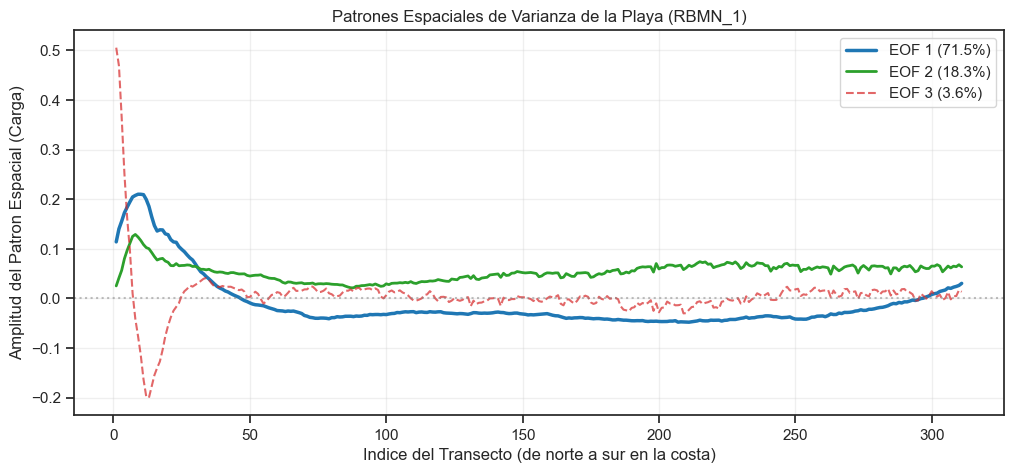

In [10]:
#SITENAME = 'RBMN_1' #Desactivar para cambiar manualmente el titulo del grafico

plt.figure(figsize=(12, 5))
x_transect_idx = np.arange(1, len(transect_cols) + 1)

plt.plot(x_transect_idx, pca.components_[0], label=f'EOF 1 ({explained_variance[0]:.1f}%)', color='#1f77b4', linewidth=2.5)
if n_components > 1:
    plt.plot(x_transect_idx, pca.components_[1], label=f'EOF 2 ({explained_variance[1]:.1f}%)', color='#2ca02c', linewidth=2)
if n_components > 2:
    plt.plot(x_transect_idx, pca.components_[2], label=f'EOF 3 ({explained_variance[2]:.1f}%)', color='#d62728', linestyle='--', alpha=0.7)

plt.axhline(0, color='gray', linestyle=':', alpha=0.5)
plt.xlabel('Indice del Transecto (de norte a sur en la costa)')
plt.ylabel('Amplitud del Patron Espacial (Carga)')
plt.title(f'Patrones Espaciales de Varianza de la Playa ({SITENAME})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. Ingenieria de Variables Físicas (Energia de Ola y Desfases)

Cálculo de la **Energía de la Ola** ($E \propto H_s^2$) y creación de variables con retardos temporales (lags) de 1 y 2 trimestres para capturar la respuesta no instantánea de la costa.

In [ ]:
# Energia de la ola
df_clean['wave_energy'] = df_clean['significant_wave_height_m'] ** 2
# Crear variables desfasadas (Lags)
df_model = df_clean.copy()
df_model['EOF_1_lag1'] = df_model['EOF_1'].shift(1)
df_model['EOF_1_lag2'] = df_model['EOF_1'].shift(2)
# 🆕 Agregamos copernicus_cols al final del bucle for
for col in era5_cols + ['wave_energy'] + copernicus_cols:
    df_model[f'{col}_lag1'] = df_model[col].shift(1)
    df_model[f'{col}_lag2'] = df_model[col].shift(2)
# Tendencia lineal temporal para capturar la dinamica cronica/antropogenica de fondo
df_model['trend'] = np.arange(len(df_model))
# Eliminar filas con NaNs creadas por el desfase (añadimos opcionalmente adt/sla lag2)
df_model = df_model.dropna(subset=['EOF_1_lag2', 'wave_energy_lag2', 'sla_copernicus_lag2']).reset_index(drop=True)
print(f"📊 Registros listos para el modelado autorregresivo: {len(df_model)} trimestres.")

📊 Registros listos para el modelado autorregresivo: 121 trimestres.


## 7. Modelado Estadístico y Evaluacion de Significancia (ARDL)

Ajuste de un modelo autorregresivo lineal multivariable para el **EOF 1 (Dinamica Transversal)** y evaluación de los pesos e importancia de cada modulador climatico.

In [12]:
# Definir variables predictoras y objetivo
predictors = [
    'EOF_1_lag1',          # Memoria temporal de la playa
    'wave_energy',         # Energia de ola instantanea
    'wave_energy_lag1',    # Energia de ola anterior (recuperacion)
    'sst_celsius',         # SST instantanea
    'sst_celsius_lag1',    # SST anterior  
    'wind_speed_m_s' ,     # Velocidad del viento 
    'sla_copernicus',      # Anomalía del Nivel del Mar instantánea (Copernicus)
    'sla_copernicus_lag1', # Anomalía del Nivel del Mar con desfase trimestral (Copernicus)
    'trend'                # Tendencia cronica
]

y = df_model['EOF_1']
X = df_model[predictors]

# 1. Entrenar modelo con variables en escala fisica (sin normalizar)
model_raw = LinearRegression()
model_raw.fit(X, y)

# Calcular metricas del modelo (son equivalentes en ambos casos)
y_pred = model_raw.predict(X)
r2 = r2_score(y, y_pred)
n, p = X.shape
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

# 2. Entrenar modelo con variables estandarizadas (Z-score) para obtener coeficientes Beta comparables
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1)).flatten()

model_scaled = LinearRegression()
model_scaled.fit(X_scaled, y_scaled)

print(f"📈 DESEMPENO DEL MODELO ARDL (Sitio: {SITENAME}):")
print(f"   R2 del modelo: {r2:.3f}")
print(f"   R2 Ajustado:   {adj_r2:.3f}")
print(f"   Intercepto:    {model_raw.intercept_:.3f}\n")

print("📋 COEFICIENTES DEL MODELO:")
print(f"   {'Variable':<20} | {'Coef Fisico':<15} | {'Coef Estandarizado (Beta)':<25}")
print("   " + "-"*68)
for col, coef_raw, coef_scaled in zip(predictors, model_raw.coef_, model_scaled.coef_):
    print(f"   {col:<20} | {coef_raw:+.4f}        | {coef_scaled:+.4f}")

📈 DESEMPENO DEL MODELO ARDL (Sitio: RBMN_1):
   R2 del modelo: 0.975
   R2 Ajustado:   0.973
   Intercepto:    354.557

📋 COEFICIENTES DEL MODELO:
   Variable             | Coef Fisico     | Coef Estandarizado (Beta)
   --------------------------------------------------------------------
   EOF_1_lag1           | +0.7621        | +0.7615
   wave_energy          | +6.2842        | +0.0225
   wave_energy_lag1     | +2.8745        | +0.0103
   sst_celsius          | -3.5496        | -0.0370
   sst_celsius_lag1     | -2.5801        | -0.0269
   wind_speed_m_s       | -46.0019        | -0.0684
   sla_copernicus       | +129.1959        | +0.0291
   sla_copernicus_lag1  | -51.5719        | -0.0117
   trend                | -2.4675        | -0.2172


### Evaluacion de Importancia de Variables mediante Modelos de Machine Learning (Random Forest)
Para validar si la "significancia" se mantiene de forma no lineal, se utiliza un modelo de **Random Forest Regressor** y se grafica la importancia intrinseca de cada variable moduladora.

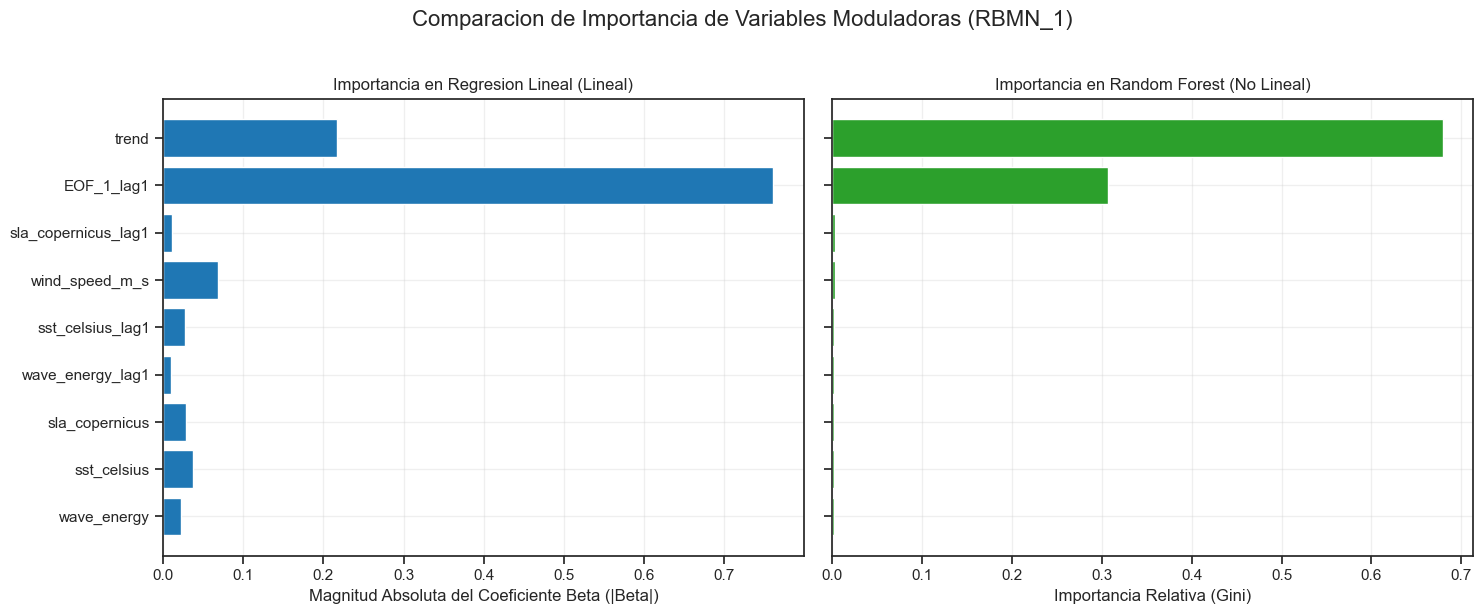

In [13]:
# 1. Ajustar Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

# 2. Calcular Importancia de Variables en Random Forest
rf_importances = rf.feature_importances_

# 3. Obtener valores absolutos de coeficientes estandarizados (Beta) de Regresion Lineal
lr_beta_abs = np.abs(model_scaled.coef_)

# 4. Crear DataFrame para facilitar el ordenamiento y graficacion
df_importance = pd.DataFrame({
    'Variable': predictors,
    'RF_Importance': rf_importances,
    'LR_Beta_Abs': lr_beta_abs
})

# Ordenar por importancia de Random Forest para consistencia visual
df_importance = df_importance.sort_values(by='RF_Importance', ascending=True)

# 5. Graficar comparacion de importancia
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# Subplot 1: Coeficientes Beta Estandarizados (Modelo Lineal)
axes[0].barh(df_importance['Variable'], df_importance['LR_Beta_Abs'], color='#1f77b4', align='center')
axes[0].set_xlabel('Magnitud Absoluta del Coeficiente Beta (|Beta|)')
axes[0].set_title('Importancia en Regresion Lineal (Lineal)')
axes[0].grid(True, alpha=0.3)

# Subplot 2: Importancia de Variables en Random Forest
axes[1].barh(df_importance['Variable'], df_importance['RF_Importance'], color='#2ca02c', align='center')
axes[1].set_xlabel('Importancia Relativa (Gini)')
axes[1].set_title('Importancia en Random Forest (No Lineal)')
axes[1].grid(True, alpha=0.3)

#SITENAME = 'RBMN_2' #Desactivar para cambiar manualmente el titulo del grafico
plt.suptitle(f'Comparacion de Importancia de Variables Moduladoras ({SITENAME})', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 8. Visualizacion

Gráfica comparando la linea de costa observada frente a la simulada por el modelo, asi como la dinamica estacional del oleaje y la anomalia del nivel del mar.

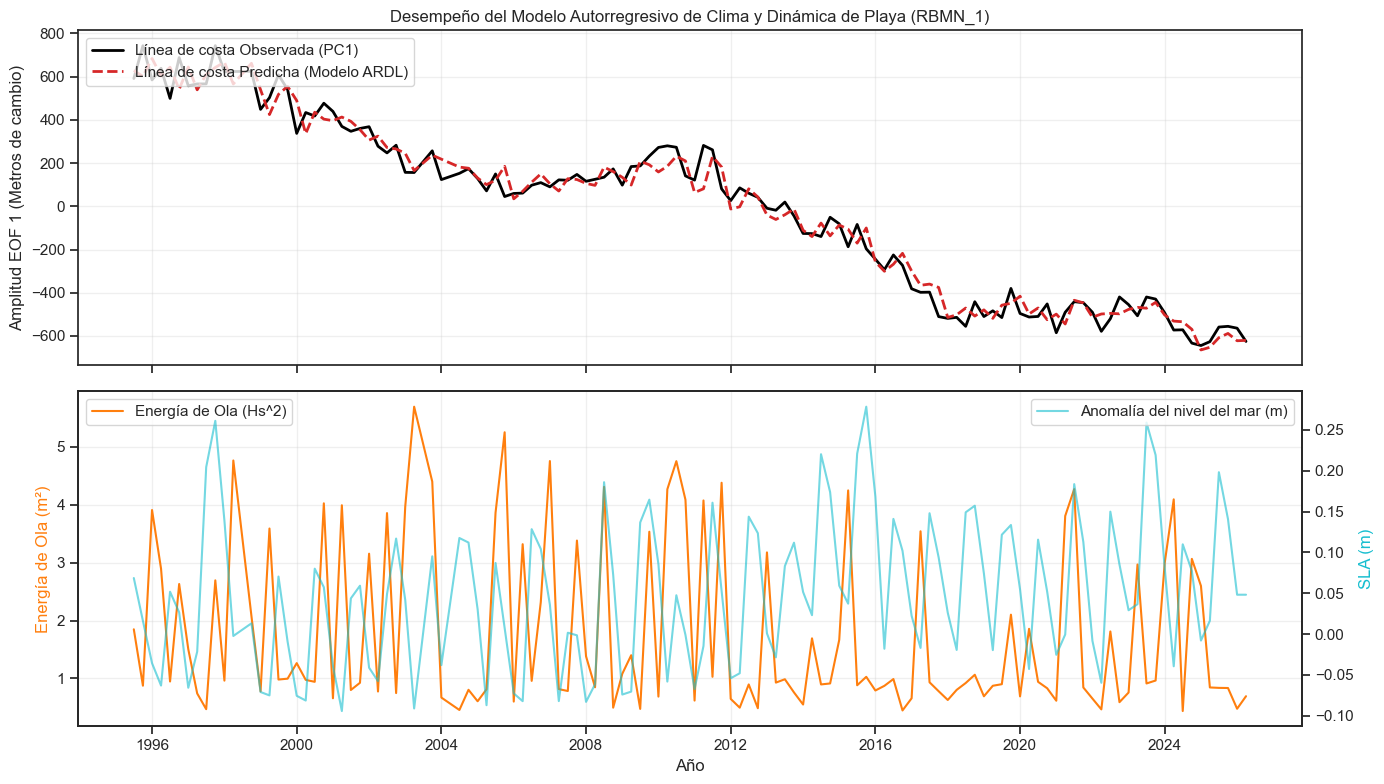

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Panel 1: Predicción de la línea de costa (PC1)
axes[0].plot(df_model['Fecha'], y, color='black', label='Línea de costa Observada (PC1)', linewidth=2)
axes[0].plot(df_model['Fecha'], y_pred, color='#d62728', label='Línea de costa Predicha (Modelo ARDL)', linestyle='--', linewidth=2)
axes[0].set_ylabel('Amplitud EOF 1 (Metros de cambio)')
axes[0].set_title(f'Desempeño del Modelo Autorregresivo de Clima y Dinámica de Playa ({SITENAME})')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# Panel 2: Variables moduladoras físicas
axes[1].plot(df_model['Fecha'], df_model['wave_energy'], color='#ff7f0e', label='Energía de Ola (Hs^2)', linewidth=1.5)
ax_twin = axes[1].twinx()
ax_twin.plot(df_model['Fecha'], df_model['sla_copernicus'], color='#17becf', label='Anomalía del nivel del mar (m)', alpha=0.6)
axes[1].set_ylabel('Energía de Ola (m²)', color='#ff7f0e')
ax_twin.set_ylabel('SLA (m)', color='#17becf')
axes[1].set_xlabel('Año')
axes[1].legend(loc='upper left')
ax_twin.legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Próximos Pasos en Google Cloud (Vertex AI)

Si en el futuro se opta por migrar este proyecto a **Vertex AI**, el flujo recomendado es:
1.  **Vertex AI Workbench:** Subir este notebook a una instancia de JupyterLab administrada en GCP.
2.  **Vertex AI Feature Store:** Almacenar los transectos de CoastSat y variables ERA5 en tablas para consumirlas de manera rapida.
3.  **AutoML Forecasting:** GCP cuenta con AutoML para series temporales que entrena multiples arquitecturas avanzadas (como *Temporal Fusion Transformers*) de manera automatica y entrega el SHAP (significancia de variables) 
¡Modifica la celda del paso 3 (`SITENAME`) para analizar otras playas del proyecto!